# Softmax Regression: multiclass digit classification

This notebook uses scikit-learn's `LogisticRegression` with `multi_class='multinomial'`, which is Softmax Regression. It predicts one of the ten digit classes (0–9).

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.9722
Log loss: 0.1020

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



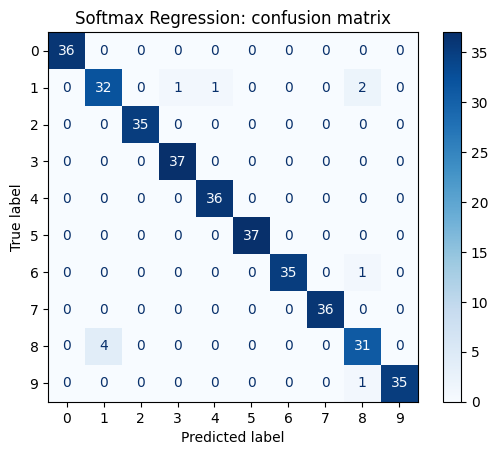

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling is recommended because Logistic Regression uses an iterative solver and L2 regularization.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(multi_class='multinomial', max_iter=2000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Log loss: {log_loss(y_test, y_proba):.4f}')
print('\nClassification report:\n', classification_report(y_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=digits.target_names).plot(cmap='Blues')
plt.title('Softmax Regression: confusion matrix')
plt.show()

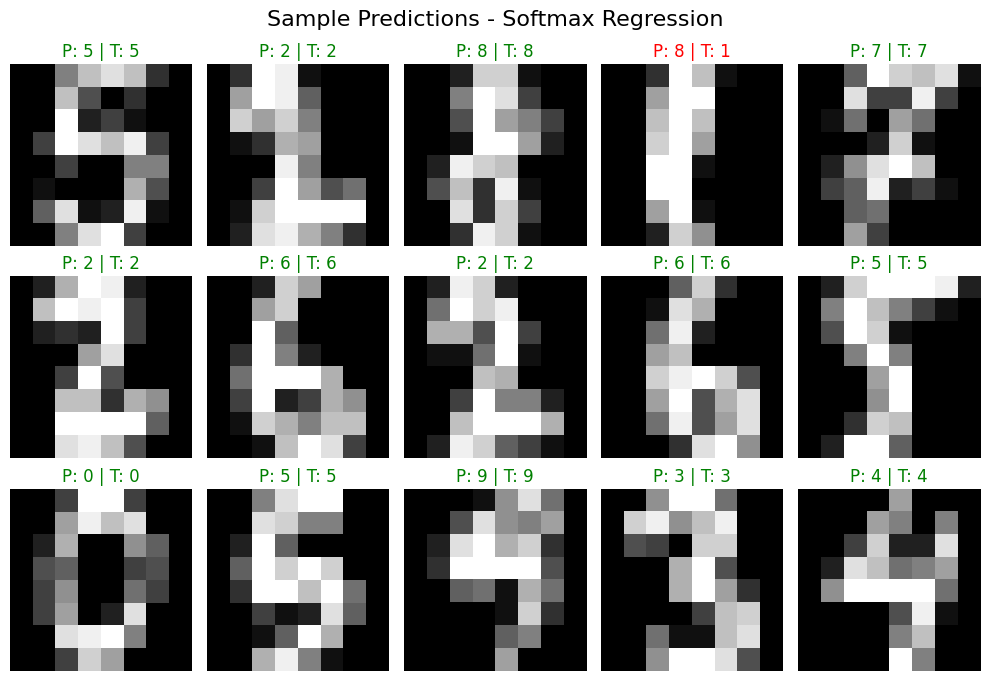

In [2]:
# Display a grid of 15 sample predictions
fig, axes = plt.subplots(3, 5, figsize=(10, 7))
axes = axes.ravel()
for i in range(15):
    img = X_test[i].reshape(8, 8)
    axes[i].imshow(img, cmap='gray')
    true_label = y_test[i]
    pred_label = y_pred[i]
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'P: {pred_label} | T: {true_label}', color=color)
    axes[i].axis('off')
plt.suptitle('Sample Predictions - Softmax Regression', fontsize=16)
plt.tight_layout()
plt.show()


## Model, loss, scaling, and evaluation

### Formula notation

- $X \in \mathbb{R}^{n \times d}$: real-valued feature matrix with $n$ examples and $d=64$ pixel features.
- $\mathbf{x}_i$: features for digit image $i$; $y_i \in \{0, \ldots, 9\}$: its true class.
- $K=10$: number of classes; $\mathbf{W} \in \mathbb{R}^{K \times d}$: learned weight matrix; $\mathbf{b} \in \mathbb{R}^{K}$: learned bias vector.
- $z_{ik}$: linear score (logit) for example $i$ and class $k$; $p_{ik}$: predicted probability of that class.

### Softmax model

$$z_{ik} = \mathbf{w}_k^T\mathbf{x}_i + b_k$$

$$p_{ik} = \frac{e^{z_{ik}}}{\sum_{j=1}^{K} e^{z_{ij}}}$$

$$\hat{y}_i = \operatorname*{argmax}_{k} p_{ik}$$

Softmax is used because the ten classes are mutually exclusive. It converts ten linear scores into non-negative probabilities that sum to $1$, then chooses the most probable digit.

### Training objective: multiclass cross-entropy

$$J = -\frac{1}{n}\sum_{i=1}^{n} \log(p_{i,y_i})$$

This loss penalizes the model when it gives low probability to the true digit. **Minimize** it: $0$ is best and there is no fixed worst value.

### Feature scaling

$$x_{ij}^{\mathrm{scaled}} = \frac{x_{ij}-\mu_j}{\sigma_j}$$

Calculate $\mu_j$ and $\sigma_j$ from training data only, then transform test data with those same values. Scaling helps the iterative solver and L2 regularization; fitting the scaler only on training data prevents leakage.

### Evaluation

$$\mathrm{Accuracy} = \frac{1}{m}\sum_{i=1}^{m}\mathbb{1}(\hat{y}_i=y_i)$$

**Maximize accuracy:** its range is $[0,1]$, where $1$ is best. The confusion matrix shows actual classes by row and predicted classes by column. `classification_report` gives precision, recall, and $F_1$ for each digit; maximize all three, where $1$ is best.

## Softmax Regression from scratch (NumPy only)

The implementation below mirrors the from-scratch Logistic Regression in the companion notebook.
It uses only NumPy for: stratified train/test split, manual feature scaling, softmax regression
trained with gradient descent, and hand-computed evaluation metrics.

In [3]:
import numpy as np
from sklearn.datasets import load_digits   # only for loading the data

# ── Load data ────────────────────────────────────────────────────────
digits = load_digits()
X, y = digits.data, digits.target   # X: (1797, 64), y: 0–9

# ── Stratified train/test split (pure NumPy) ─────────────────────────
def stratified_split_numpy(X, y, test_size=0.2, seed=42):
    np.random.seed(seed)
    train_idx, test_idx = [], []

    for label_value in np.unique(y):
        class_indices = np.where(y == label_value)[0]
        shuffled = np.random.permutation(class_indices)
        n_test = int(len(shuffled) * test_size)
        test_idx.extend(shuffled[:n_test])
        train_idx.extend(shuffled[n_test:])

    train_idx = np.random.permutation(train_idx)
    test_idx  = np.random.permutation(test_idx)

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = stratified_split_numpy(X, y, test_size=0.2, seed=42)

# ── Manual feature scaling (fit on train only) ───────────────────────
def fit_scaler(X):
    mean = X.mean(axis=0)
    std  = X.std(axis=0)
    std[std == 0] = 1.0          # avoid division by zero for constant features
    return mean, std

def apply_scaler(X, mean, std):
    return (X - mean) / std

mean, std = fit_scaler(X_train)
X_train_scaled = apply_scaler(X_train, mean, std)
X_test_scaled  = apply_scaler(X_test, mean, std)

# ── Helper: add bias column ──────────────────────────────────────────
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

# ── Softmax function (numerically stable) ────────────────────────────
def softmax(Z):
    """Row-wise softmax.  Z: (n, K) -> probabilities (n, K)."""
    exp_Z = np.exp(Z - Z.max(axis=1, keepdims=True))   # subtract row-max for stability
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)

# ── One-hot encoding ─────────────────────────────────────────────────
def one_hot(y, K):
    """Convert label vector y (n,) to one-hot matrix (n, K)."""
    oh = np.zeros((len(y), K))
    oh[np.arange(len(y)), y] = 1.0
    return oh

# ── Softmax regression: fit with gradient descent ────────────────────
def fit_softmax_regression(X, y, lr=0.1, n_iters=1000):
    """
    Gradient descent for multiclass cross-entropy.

    Parameters
    ----------
    X : array of shape (n, d) – already scaled features.
    y : array of shape (n,)   – integer class labels 0..K-1.
    lr : learning rate.
    n_iters : number of gradient-descent iterations.

    Returns
    -------
    W : array of shape (d+1, K) – learned weight matrix (first row = biases).
    """
    X_b = add_bias(X)                       # (n, d+1)
    n_samples, n_features = X_b.shape
    K = len(np.unique(y))
    Y_oh = one_hot(y, K)                    # (n, K)
    W = np.zeros((n_features, K))           # (d+1, K)

    for i in range(n_iters):
        Z = X_b @ W                         # (n, K) logits
        P = softmax(Z)                      # (n, K) probabilities

        # ── Compute Gradients ───────────────────────────────────────────────
        # The gradient of the cross-entropy loss w.r.t weights simplifies beautifully to:
        # (Inputs)^T * (Predicted Probs - True One-Hot Labels) / batch_size
        # Shape analysis: X_b is (n_samples, d+1), (P - Y_oh) is (n_samples, K)
        # X_b.T @ (P - Y_oh) yields (d+1, K) matching our weight matrix!
        gradient = (1 / n_samples) * X_b.T @ (P - Y_oh)   # (d+1, K)
        
        # ── Update Weights ──────────────────────────────────────────────────
        # Step in the opposite direction of the gradient to minimize loss
        W -= lr * gradient

        if i % 200 == 0:
            # cross-entropy loss
            loss = -np.mean(np.log(P[np.arange(n_samples), y] + 1e-9))
            print(f'Iter {i:4d}: loss = {loss:.4f}')

    return W

# ── Predict helpers ──────────────────────────────────────────────────
def predict_proba_softmax(X, W):
    return softmax(add_bias(X) @ W)

def predict_softmax(X, W):
    return np.argmax(predict_proba_softmax(X, W), axis=1)

# ── Train ────────────────────────────────────────────────────────────
W = fit_softmax_regression(X_train_scaled, y_train, lr=0.1, n_iters=1000)

# ── Predict ──────────────────────────────────────────────────────────
y_pred = predict_softmax(X_test_scaled, W)
y_proba = predict_proba_softmax(X_test_scaled, W)

# ── Manual metrics ───────────────────────────────────────────────────
accuracy = np.mean(y_pred == y_test)
cross_ent = -np.mean(np.log(y_proba[np.arange(len(y_test)), y_test] + 1e-9))

# Per-class precision, recall, F1
K = len(np.unique(y_test))
print(f'\nAccuracy:        {accuracy:.4f}')
print(f'Cross-entropy:   {cross_ent:.4f}')
print(f'\n{"Class":>5}  {"Precision":>9}  {"Recall":>6}  {"F1":>6}  {"Support":>7}')
print('-' * 44)
for k in range(K):
    tp = np.sum((y_pred == k) & (y_test == k))
    fp = np.sum((y_pred == k) & (y_test != k))
    fn = np.sum((y_pred != k) & (y_test == k))
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    support = int(np.sum(y_test == k))
    print(f'{k:5d}  {prec:9.4f}  {rec:6.4f}  {f1:6.4f}  {support:7d}')

# Confusion matrix
cm = np.zeros((K, K), dtype=int)
for true, pred in zip(y_test, y_pred):
    cm[true, pred] += 1
print(f'\nConfusion matrix (rows = actual, cols = predicted):\n{cm}')

Iter    0: loss = 2.3026
Iter  200: loss = 0.1990
Iter  400: loss = 0.1376
Iter  600: loss = 0.1106
Iter  800: loss = 0.0944

Accuracy:        0.9577
Cross-entropy:   0.1345

Class  Precision  Recall      F1  Support
--------------------------------------------
    0     1.0000  1.0000  1.0000       35
    1     0.9429  0.9167  0.9296       36
    2     0.9714  0.9714  0.9714       35
    3     0.9714  0.9444  0.9577       36
    4     0.9730  1.0000  0.9863       36
    5     0.9211  0.9722  0.9459       36
    6     1.0000  0.9722  0.9859       36
    7     0.9706  0.9429  0.9565       35
    8     0.9412  0.9412  0.9412       34
    9     0.8919  0.9167  0.9041       36

Confusion matrix (rows = actual, cols = predicted):
[[35  0  0  0  0  0  0  0  0  0]
 [ 0 33  0  0  0  0  0  0  0  3]
 [ 0  0 34  0  0  0  0  0  1  0]
 [ 0  0  0 34  0  2  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  1  0 35  0  0  0  0]
 [ 0  1  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  1  0  0 33  0  1]
 

In [4]:
# WIP
# softmax regression predicts the digits
# 
import numpy as np
from sklearn.datasets import load_digits

# load & understand data
data = load_digits()
x, y = data.data, data.target
# print(x.shape)
# print(x[:1,:])
# print(data.feature_names)
# print(data.target_names)
# print(data.DESCR)


# train/test split
def train_test_split_numpy(x, y, test_size=0.2, seed=42):
    np.random.seed(seed)
    train_idx, test_idx = [], []
    # for each label I want same proportion of data in train and test
    
    for label in np.unique(y):
        class_indices = np.where(y == label)[0]
        shuffled = np.random.permutation(class_indices)
        num_test = int(len(shuffled) * test_size)
        test_idx.extend(shuffled[:num_test])
        train_idx.extend(shuffled[num_test:])
    train_idx = np.random.permutation(train_idx)
    test_idx = np.random.permutation(test_idx)

    return x[train_idx], x[test_idx], y[train_idx], y[test_idx]

x_train, x_test, y_train, y_test = train_test_split_numpy(x, y, test_size=0.2, seed=42)

def fit_scaler(x):
    mean = x.mean(axis=0)
    std = x.std(axis=0)
    std[std == 0] = 1.0 # avoid division by zero
    return mean, std

def apply_scaler(x, mean, std):
    return (x - mean) / std

mean, std = fit_scaler(x_train)
x_train_scaled = apply_scaler(x_train, mean, std)
x_test_scaled = apply_scaler(x_test, mean, std)

# add bias
def add_bias(x):
    ones = np.ones((x.shape[0], 1))
    return np.hstack([ones, x])

# softmax
def softmax(z):
    # numerical stable version
    exp_z = np.exp(z - z.max(axis=1, keepdims=True))
    return exp_z / exp_z.sum(axis=1, keepdims=True)
    
    # normal version
    # e_z = np.exp(z)
    # sum_e_zi = e_z.sum(axis=1, keepdims=True)
    # return e_z / sum_e_zi

# one hot encoding
def one_hot(y, k):
    oh = np.zeros((len(y), k))
    oh[np.arange(len(y)), y] = 1.0
    return oh


# train
def fit_softmax_regression(x, y, lr=0.01, num_iters=1000):
    # x -> (n, d)
    x_b = add_bias(x) # (n, d + 1)
    num_samples, num_features = x_b.shape # x_b not x: bias column counts
    k = len(np.unique(y)) # k = 10
    y_oh = one_hot(y, k) # (n, k)
    w = np.zeros((num_features, k)) # (d + 1, k)

    for i in range(num_iters):
        z = x_b @ w # (n, d + 1) @ (d + 1, k) -> (n, k) logits
        p = softmax(z) #(n, k) probablities

        # gradients
        # matrix gradient?
        gradient = (1 / num_samples) * x_b.T @ (p - y_oh) # (d + 1, k)

        # update weights
        w -= lr * gradient

        if i % 200 == 0:
            loss = -np.mean(np.log(p[np.arange(num_samples), y] + 1e-9))
            print(f"Iter {i:4d}: loss = {loss:.4f}")
    return w

# train
w = fit_softmax_regression(x_train_scaled, y_train, lr=0.01, num_iters=1000)

# predict
def predict_proba_softmax(x, w):
    return softmax(add_bias(x) @ w)

def predict_softmax(x, w):
    return np.argmax(predict_proba_softmax(x, w), axis=1)

y_pred = predict_softmax(x_test_scaled, w)
y_proba = predict_proba_softmax(x_test_scaled, w)

accuracy = np.mean(y_pred == y_test)
cross_ent = -np.mean(np.log(y_proba[np.arange(len(y_test)), y_test] + 1e-9))
print(f'\nAccuracy:        {accuracy:.4f}')
print(f'Cross-entropy:   {cross_ent:.4f}')

# per class, precision, recall, f1
num_classes = len(np.unique(y_test))
print(f'\n{"Class":>5}  {"Precision":>9}  {"Recall":>6}  {"F1":>6}  {"Support":>7}')
print('-' * 44)
for k in range(num_classes):
    tp = np.sum((y_pred == k) & (y_test == k))
    fp = np.sum((y_pred == k) & (y_test != k))
    fn = np.sum((y_pred != k) & (y_test == k))
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    support = int(np.sum(y_test == k))
    print(f'{k:5d}  {prec:9.4f}  {rec:6.4f}  {f1:6.4f}  {support:7d}')

# Confusion matrix
cm = np.zeros((num_classes, num_classes), dtype=int)
for true, pred in zip(y_test, y_pred):
    cm[true, pred] += 1
print(f'\nConfusion matrix (rows = actual, cols = predicted):\n{cm}')


Iter    0: loss = 2.3026
Iter  200: loss = 0.7819
Iter  400: loss = 0.5066
Iter  600: loss = 0.3948
Iter  800: loss = 0.3328

Accuracy:        0.9493
Cross-entropy:   0.3115

Class  Precision  Recall      F1  Support
--------------------------------------------
    0     1.0000  1.0000  1.0000       35
    1     0.8889  0.8889  0.8889       36
    2     0.9714  0.9714  0.9714       35
    3     0.9706  0.9167  0.9429       36
    4     1.0000  1.0000  1.0000       36
    5     0.9459  0.9722  0.9589       36
    6     1.0000  0.9444  0.9714       36
    7     0.9189  0.9714  0.9444       35
    8     0.9677  0.8824  0.9231       34
    9     0.8500  0.9444  0.8947       36

Confusion matrix (rows = actual, cols = predicted):
[[35  0  0  0  0  0  0  0  0  0]
 [ 0 32  0  0  0  0  0  0  0  4]
 [ 0  1 34  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  2  0  1  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 35  0  1  0  0]
 [ 0  2  0  0  0  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 34  0  1]
 

In [5]:
# print(data.images.shape)
# data.images[0]
# data.images.flatten()
# data.images.reshape(data.images.shape[0], -1).shape
# ix = np.where(y == 1)[0]
# print(ix)
# np.random.permutation(ix)
# data.data[ix]

